   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

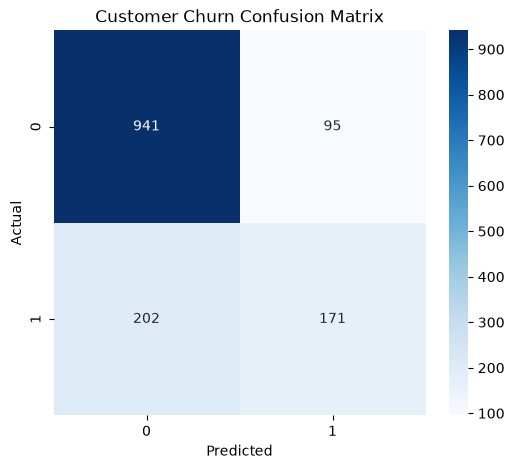

                                  Feature  Importance
3                            TotalCharges    0.189701
1                                  tenure    0.175710
2                          MonthlyCharges    0.172418
10            InternetService_Fiber optic    0.036053
28         PaymentMethod_Electronic check    0.035302
25                      Contract_Two year    0.030435
13                     OnlineSecurity_Yes    0.029238
4                             gender_Male    0.027423
26                   PaperlessBilling_Yes    0.025295
5                             Partner_Yes    0.024209
19                        TechSupport_Yes    0.023697
24                      Contract_One year    0.021924
15                       OnlineBackup_Yes    0.021785
6                          Dependents_Yes    0.020815
0                           SeniorCitizen    0.019905
9                       MultipleLines_Yes    0.019596
17                   DeviceProtection_Yes    0.019235
23                    Stream

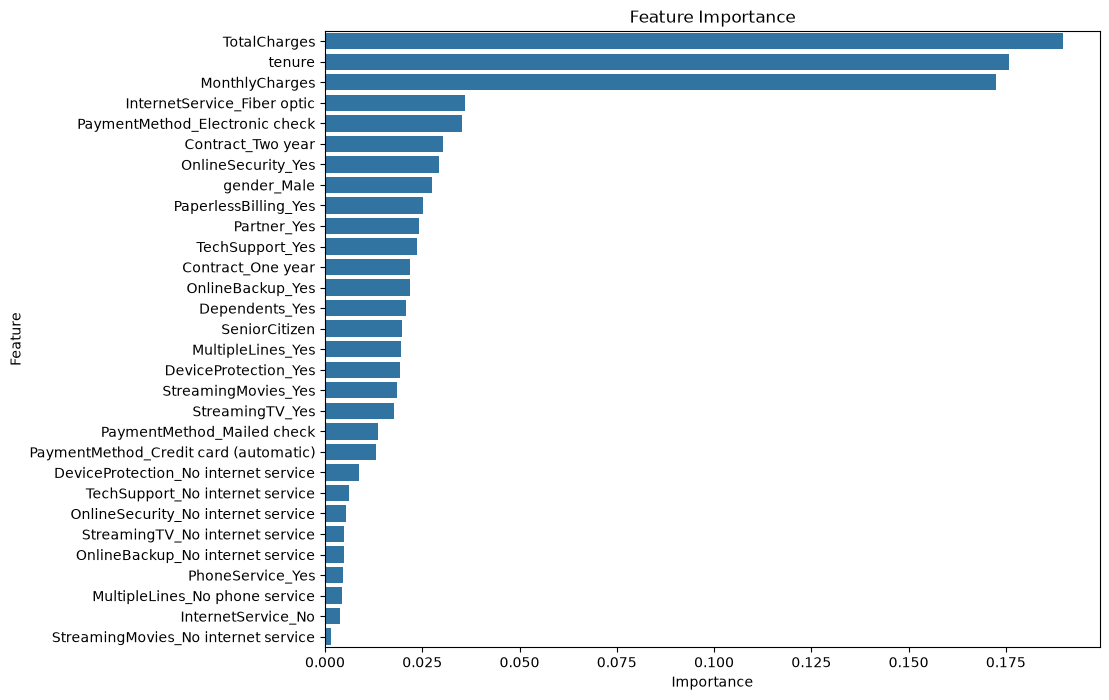

Model Saved Successfully!


In [1]:
# ==========================
# CUSTOMER CHURN PREDICTION
# ==========================

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("data.csv")

# ==========================
# Data Preprocessing
# ==========================

# Remove Customer ID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert all categorical columns
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.info())

# ==========================
# Separate X and y
# ==========================

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================
# Random Forest Model
# ==========================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================
# Prediction
# ==========================

y_pred = model.predict(X_test)

# ==========================
# Accuracy
# ==========================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy*100)

# ==========================
# Classification Report
# ==========================

print(classification_report(y_test, y_pred))

# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")
plt.show()

# ==========================
# Feature Importance
# ==========================

importance = model.feature_importances_

feature = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature = feature.sort_values(
    by="Importance",
    ascending=False
)

print(feature)

plt.figure(figsize=(10,8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature
)

plt.title("Feature Importance")
plt.show()

# ==========================
# Save Model
# ==========================

pickle.dump(model, open("customer_churn_model.pkl", "wb"))

print("Model Saved Successfully!")

In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data.csv")

In [3]:
# Remove Customer ID
df.drop("customerID", axis=1, inplace=True)

In [4]:
# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [5]:
# Fill Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [6]:
# Convert all categorical columns
df = pd.get_dummies(df, drop_first=True)


In [7]:
print(df.head())
print(df.info())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
y_pred = model.predict(X_test)


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy*100)

Accuracy : 0.7892122072391767
Accuracy Percentage : 78.92122072391767


In [12]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1036
        True       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



[[941  95]
 [202 171]]


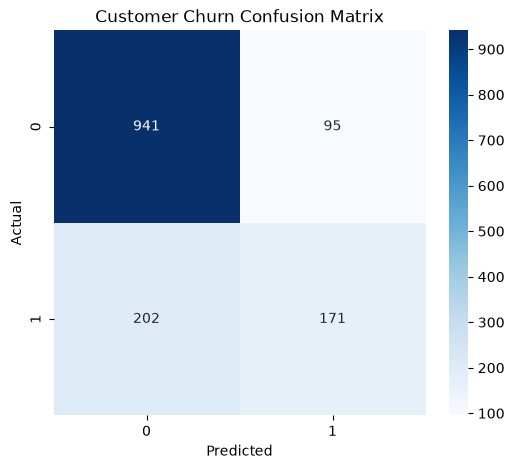

In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")
plt.show()

                                  Feature  Importance
3                            TotalCharges    0.189701
1                                  tenure    0.175710
2                          MonthlyCharges    0.172418
10            InternetService_Fiber optic    0.036053
28         PaymentMethod_Electronic check    0.035302
25                      Contract_Two year    0.030435
13                     OnlineSecurity_Yes    0.029238
4                             gender_Male    0.027423
26                   PaperlessBilling_Yes    0.025295
5                             Partner_Yes    0.024209
19                        TechSupport_Yes    0.023697
24                      Contract_One year    0.021924
15                       OnlineBackup_Yes    0.021785
6                          Dependents_Yes    0.020815
0                           SeniorCitizen    0.019905
9                       MultipleLines_Yes    0.019596
17                   DeviceProtection_Yes    0.019235
23                    Stream

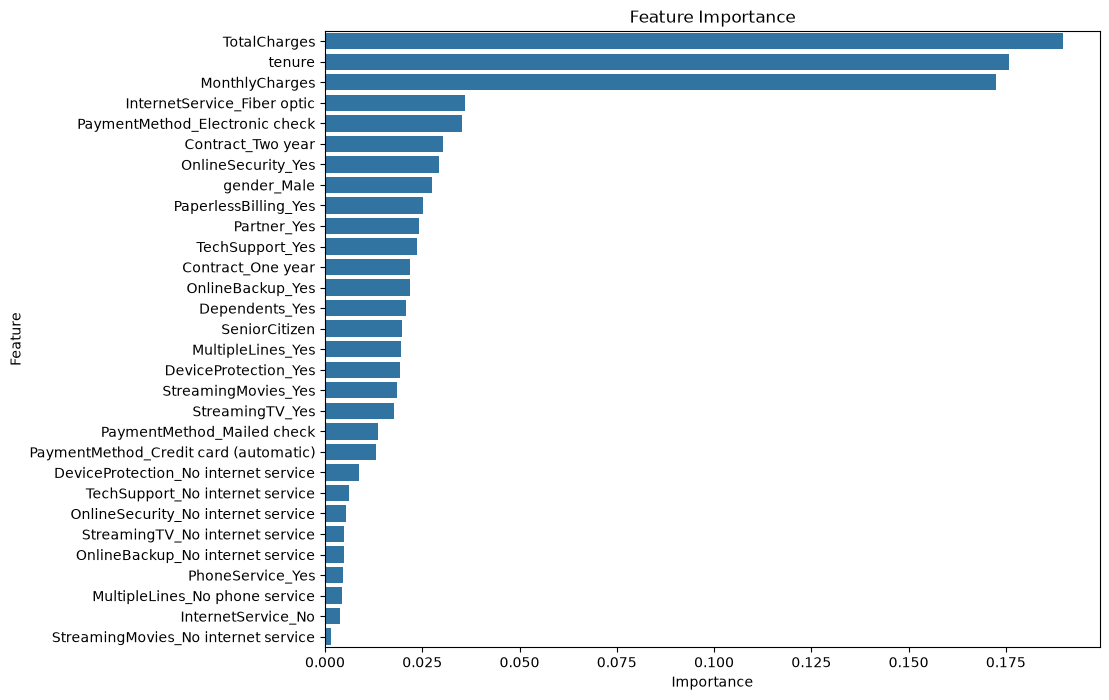

In [14]:
importance = model.feature_importances_

feature = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature = feature.sort_values(
    by="Importance",
    ascending=False
)

print(feature)

plt.figure(figsize=(10,8))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature
)

plt.title("Feature Importance")
plt.show()


In [ ]:
pickle.dump(model, open("customer_churn_model.pkl", "wb"))

print("Model Saved Successfully!")